# 📊 Báo Cáo 5 Bước - Tương Tác Facebook
Notebook ngắn gọn, dễ chạy lại để báo cáo: dưới đây là tóm tắt các bước và công thức chính (tiếng Việt).

1) Bước 0 — Khám phá dữ liệu (Explore)
- Mục tiêu: kiểm tra kích thước, cột, phân bố nhanh và missing.
- Công thức hữu ích: Mean = sum(x)/n；Median = giá trị giữa；Missing% = (số ô thiếu / tổng ô) × 100

2) Bước 1 — Làm sạch dữ liệu (Clean)
- Mục tiêu: chuẩn hoá datetime, thay NA cho số bằng 0, loại trùng, tạo `Total_Engagement`.
- Công thức: Total_Engagement = Likes + Comments + Shares (hoặc tổng các cột tương tác theo loại)

3) Bước 2 — Hiệu quả nội dung (Content effectiveness)
- Mục tiêu: so sánh 5 loại nội dung: Photo, Video, Status, Link, Live.
- Công thức chính: Rate = Tổng tương tác của loại / Tổng số bài của loại

4) Bước 3 — Tương tác theo thời gian (Time-series)
- Mục tiêu: gộp theo tháng, xem xu hướng và tốc độ tăng trưởng.
- Công thức: Monthly_Total = SUM(tương tác trong tháng)；Growth_% = (Tháng hiện tại - Tháng trước)/Tháng trước × 100

5) Bước 4 — Trực quan hóa tổng hợp (Visualization)
- Mục tiêu: trình bày Pie (thành phần), Bar (engagement per post), Boxplot (phân bố), Trend (xu hướng).
- Công thức phụ: Composition% = (Tổng loại / Tổng tất cả) × 100

6) Bước 5 — Dự đoán tương tác (Prediction - ví dụ)
- Mục tiêu: mô phỏng model (RandomForest) dự đoán `Total_Engagement` từ các biến có sẵn.
- Công thức đánh giá: RMSE = sqrt(mean((y-ŷ)^2))；MAE = mean(|y-ŷ|)；R² = 1 - SS_res/SS_tot

Dữ liệu sử dụng: `data/facebook_updated_even_2022_2024.csv` — chạy các ô theo thứ tự để tái tạo các bảng và biểu đồ trong báo cáo.

In [1]:
# Thư viện và cấu hình biểu đồ
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
print('✅ Đã tải thư viện')

✅ Đã tải thư viện


---
## Bước 0 — Khám phá dữ liệu
Tải file CSV và hiển thị vài dòng đầu cùng danh sách cột chính sử dụng trong phân tích.

**Công thức hữu ích:**
- Trung bình: Mean = sum(x)/n
- Trung vị: Median = giá trị giữa sau khi sắp xếp
- Tỷ lệ thiếu: Missing% = (số ô thiếu / tổng ô) × 100

In [2]:
# Tải dữ liệu
try:
    pd
except NameError:
    import pandas as pd
try:
    np
except NameError:
    import numpy as np
try:
    plt
except NameError:
    import matplotlib.pyplot as plt
try:
    sns
except NameError:
    import seaborn as sns
try:
    train_test_split
except NameError:
    from sklearn.model_selection import train_test_split
try:
    RandomForestRegressor
except NameError:
    from sklearn.ensemble import RandomForestRegressor
try:
    mean_squared_error
except NameError:
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
path = r"C:\Users\Admin\PycharmProjects\PythonProject1\cd3\facebook_updated_even_2022_2024.csv"
df = pd.read_csv(path)
print('Số hàng, số cột:', df.shape)
print('Ví dụ các cột:', list(df.columns)[:20])
df.head()

Số hàng, số cột: (195, 35)
Ví dụ các cột: ['Page Name', 'Beginning Of Interval', 'Page Likes', 'Page Like Growth', 'Followers', 'Follower Growth', 'Post Count', 'Total Interactions', 'Interaction Growth', 'Interaction Rate', 'Interactions Per Post', 'Comments', 'Shares', 'Total Reactions (including Likes)', 'Likes', 'Angry', 'Haha', 'Wow', 'Sad', 'Love']


,Page Name,Beginning Of Interval,Page Likes,Page Like Growth,Followers,Follower Growth,Post Count,Total Interactions,Interaction Growth,Interaction Rate,...,Link Interaction Rate,Status Posts,Status Interactions,Status Interaction Rate,Facebook Video Posts (excluding Live),Facebook Video Interactions (excluding Live),Facebook Video Interaction Rate (excluding Live),Facebook Live Video Posts,Facebook Live Interactions,Facebook Live Interaction Rate
0,Facebook 360,2022-01-01 00:00:00.000000000,3409879,0.01%,3511083,0%,0,0,0%,0%,...,NaN,0,0,NaN,0,0,NaN,0,0,NaN
1,Facebook,2022-01-06 15:27:50.103092783,178009471,0.80%,178318547,0.80%,0,0,0%,0%,...,NaN,0,0,NaN,0,0,NaN,0,0,NaN
2,Facebook,2022-01-12 06:55:40.206185567,177997606,0.79%,178563285,0.80%,0,0,0%,0%,...,NaN,0,0,NaN,0,0,NaN,0,0,NaN
3,Facebook,2022-01-17 22:23:30.309278350,178009511,0.80%,178009598,0.80%,0,0,0%,0%,...,NaN,0,0,NaN,0,0,NaN,0,0,NaN
4,Facebook for Creators,2022-01-23 13:51:20.412371134,533984,8.74%,643159,5.05%,17,25256,0%,0.23%,...,NaN,0,0,NaN,1,1434,0.27%,0,0,NaN


---
## Bước 1 — Làm sạch dữ liệu
Mục tiêu: điền giá trị thiếu, chuẩn hoá datetime, loại bản sao, tạo `Total_Engagement`
Công thức: Total_Engagement = Likes + Comments + Shares

In [3]:
df_clean = df.copy()
# Điền giá trị thiếu cho các cột số liên quan đến tương tác
for col in ['Likes','Comments','Shares','Followers','Page Likes','Post Count']:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce').fillna(0)
# Chuẩn hoá cột datetime (nếu có)
if 'Beginning Of Interval' in df_clean.columns:
    df_clean['Beginning Of Interval'] = pd.to_datetime(df_clean['Beginning Of Interval'], errors='coerce')
# Loại bỏ hàng trùng lặp
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
# Tạo Total_Engagement (dùng fallback nếu thiếu Likes/Comments/Shares)
if set(['Likes','Comments','Shares']).issubset(df_clean.columns):
    df_clean['Total_Engagement'] = df_clean['Likes'] + df_clean['Comments'] + df_clean['Shares']
else:
    # Cộng các cột tương tác theo loại nội dung nếu có
    content_cols = [
        'Photo Interactions', 'Facebook Video Interactions (excluding Live)',
        'Status Interactions', 'Link Interactions', 'Facebook Live Interactions'
    ]
    existing = [c for c in content_cols if c in df_clean.columns]
    if existing:
        df_clean['Total_Engagement'] = df_clean[existing].sum(axis=1)
    else:
        df_clean['Total_Engagement'] = 0
print('Đã làm sạch — hàng, cột:', df_clean.shape)
print('Mẫu Total_Engagement:', df_clean['Total_Engagement'].head().tolist())
df_clean.info()

Đã làm sạch — hàng, cột: (195, 36)
Mẫu Total_Engagement: [0, 0, 0, 0, 21338]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 36 columns):
 #   Column                                            Non-Null Count  Dtype         
---  ------                                            --------------  -----         
 0   Page Name                                         195 non-null    object        
 1   Beginning Of Interval                             195 non-null    datetime64[ns]
 2   Page Likes                                        195 non-null    int64         
 3   Page Like Growth                                  195 non-null    object        
 4   Followers                                         195 non-null    int64         
 5   Follower Growth                                   195 non-null    object        
 6   Post Count                                        195 non-null    int64         
 7   Total Interactions                     

---
## Bước 2 — Hiệu quả nội dung (5 loại)
Sử dụng 5 loại: Photo, Video, Status, Link, Live.
Công thức: Tỷ lệ tương tác = Tổng tương tác của loại / Tổng số bài của loại đó

Công thức: Rate = Tổng tương tác của loại / Tổng số bài của loại
  Content   Total  Posts         Rate
0   Video  446628    288  1550.791667
1   Photo  349493    275  1270.883636
2    Live  307681     52  5916.942308
3  Status  239460     36  6651.666667
4    Link   20618     14  1472.714286


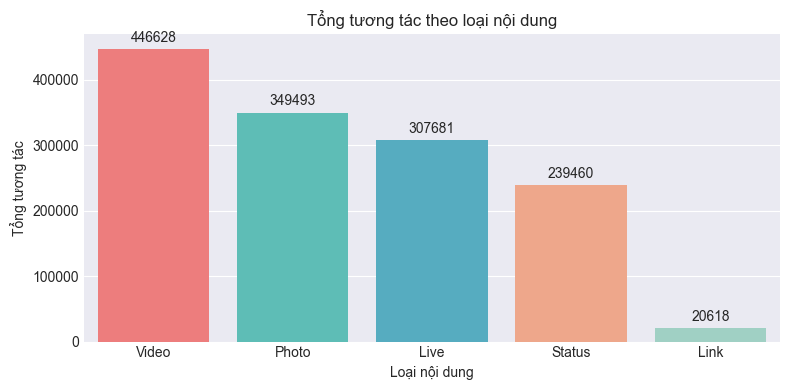

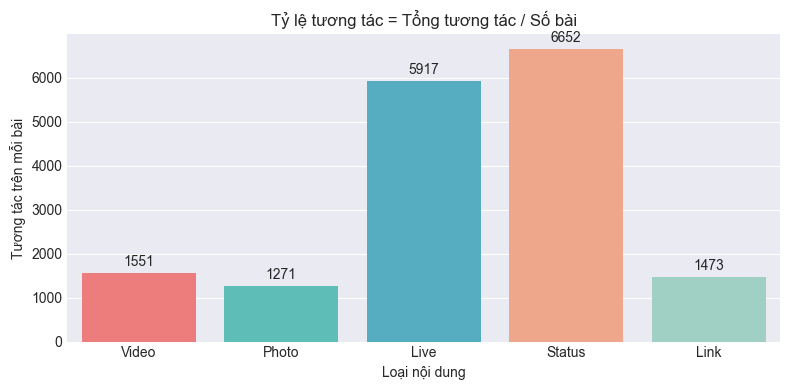


===== ĐÁNH GIÁ KẾT QUẢ BIỂU ĐỒ =====
1. Loại nội dung tạo nhiều tương tác nhất là Video với 446,628 lượt tương tác.
2. Loại nội dung hiệu quả nhất (tương tác/bài) là Status với trung bình 6,652 tương tác mỗi bài.
3. Loại nội dung được đăng nhiều nhất là Video với 288 bài đăng.
4. Loại nội dung kém hiệu quả nhất là Photo chỉ đạt 1,271 tương tác/bài.

===== GỢI Ý CHIẾN LƯỢC =====
- Ưu tiên tăng ngân sách và tần suất cho các định dạng có Rate cao.
- Nếu mục tiêu reach và viral: tập trung Video / Live.
- Nếu mục tiêu duy trì hiện diện: dùng Photo vì số lượng đăng cao và ổn định.
- Giảm bớt hoặc tối ưu lại các định dạng có hiệu suất thấp.

===== BẢNG SCORE HIỆU QUẢ =====
  Content         Score
3    Link  10253.692857
2  Status   6419.125000
4    Live   4968.786538
1   Video   1090.123958
0   Photo   1000.369818


In [4]:
# Định nghĩa tên cột cho từng loại nội dung (chỉnh nếu CSV khác tên)
content_cols = {
    'Photo': 'Photo Interactions',
    'Video': 'Facebook Video Interactions (excluding Live)',
    'Status': 'Status Interactions',
    'Link': 'Link Interactions',
    'Live': 'Facebook Live Interactions'
}
posts_cols = {
    'Photo': 'Photo Posts',
    'Video': 'Facebook Video Posts (excluding Live)',
    'Status': 'Status Posts',
    'Link': 'Link Posts',
    'Live': 'Facebook Live Video Posts'
}
# Tổng và tỷ lệ
totals = {k: df_clean.get(col, pd.Series(dtype=float)).sum() for k, col in content_cols.items()}
posts_total = {k: max(df_clean.get(col, pd.Series(dtype=float)).sum(), 1) for k, col in posts_cols.items()}
rates = {k: totals[k] / posts_total[k] for k in totals}
content_df = pd.DataFrame([{'Content':k,'Total':totals[k],'Posts':posts_total[k],'Rate':rates[k]} for k in totals])
content_df = content_df.sort_values('Total', ascending=False).reset_index(drop=True)
print('Công thức: Rate = Tổng tương tác của loại / Tổng số bài của loại')
print(content_df)
# Vẽ biểu đồ cho Bước 2: Tổng tương tác và Tỷ lệ tương tác
colors = ['#FF6B6B','#4ECDC4','#45B7D1','#FFA07A','#98D8C8']
plt.figure(figsize=(8,4))
ax = sns.barplot(x='Content', y='Total', data=content_df, palette=colors)

# Hiển thị số trên cột
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)
plt.title('Tổng tương tác theo loại nội dung')
plt.ylabel('Tổng tương tác')
plt.xlabel('Loại nội dung')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4))
ax = sns.barplot(x='Content', y='Rate', data=content_df, palette=colors)

# Hiển thị số trên cột
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)
plt.title('Tỷ lệ tương tác = Tổng tương tác / Số bài')
plt.ylabel('Tương tác trên mỗi bài')
plt.xlabel('Loại nội dung')
plt.tight_layout()
plt.show()

# INSIGHT KẾT QUẢ
print("\n===== ĐÁNH GIÁ KẾT QUẢ BIỂU ĐỒ =====")

# Loại có tổng tương tác cao nhất
top_total = content_df.loc[content_df['Total'].idxmax()]

# Loại có hiệu suất cao nhất
top_rate = content_df.loc[content_df['Rate'].idxmax()]

# Loại đăng nhiều nhất
top_post = content_df.loc[content_df['Posts'].idxmax()]

print(f"1. Loại nội dung tạo nhiều tương tác nhất là {top_total['Content']} "
      f"với {top_total['Total']:,.0f} lượt tương tác.")

print(f"2. Loại nội dung hiệu quả nhất (tương tác/bài) là {top_rate['Content']} "
      f"với trung bình {top_rate['Rate']:,.0f} tương tác mỗi bài.")

print(f"3. Loại nội dung được đăng nhiều nhất là {top_post['Content']} "
      f"với {top_post['Posts']:,.0f} bài đăng.")

# Nhóm hiệu suất thấp
low_rate = content_df.sort_values('Rate').iloc[0]

print(f"4. Loại nội dung kém hiệu quả nhất là {low_rate['Content']} "
      f"chỉ đạt {low_rate['Rate']:,.0f} tương tác/bài.")

# Nhận xét chiến lược
print("\n===== GỢI Ý CHIẾN LƯỢC =====")

print("- Ưu tiên tăng ngân sách và tần suất cho các định dạng có Rate cao.")
print("- Nếu mục tiêu reach và viral: tập trung Video / Live.")
print("- Nếu mục tiêu duy trì hiện diện: dùng Photo vì số lượng đăng cao và ổn định.")
print("- Giảm bớt hoặc tối ưu lại các định dạng có hiệu suất thấp.")

# SCORE HIỆU QUẢ NÂNG CAO
# Score = (Interactions*0.4 + Shares*0.3 + Comments*0.3) / Posts
scores = {}

for k in content_cols:
    interactions = totals[k]
    shares = df_clean['Shares'].sum() if 'Shares' in df_clean.columns else 0
    comments = df_clean['Comments'].sum() if 'Comments' in df_clean.columns else 0
    posts = posts_total[k]

    scores[k] = (interactions*0.4 + shares*0.3 + comments*0.3) / posts

score_df = pd.DataFrame({
    'Content': list(scores.keys()),
    'Score': list(scores.values())
}).sort_values('Score', ascending=False)

print("\n===== BẢNG SCORE HIỆU QUẢ =====")
print(score_df)

---
## Bước 3 — Tương tác theo thời gian
Gộp theo tháng và tính tốc độ tăng trưởng
Công thức:\nMonthly_Total_type = SUM(tương tác của loại) trong tháng\nGrowth_Rate = (Tháng hiện tại - Tháng trước)/Tháng trước × 100

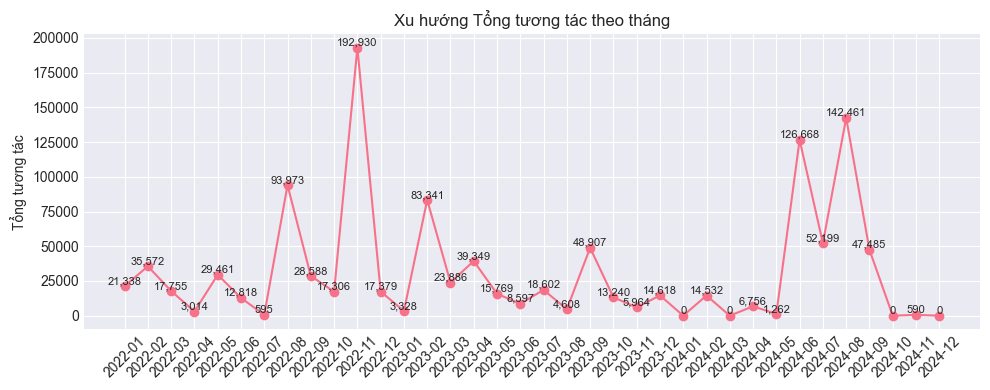

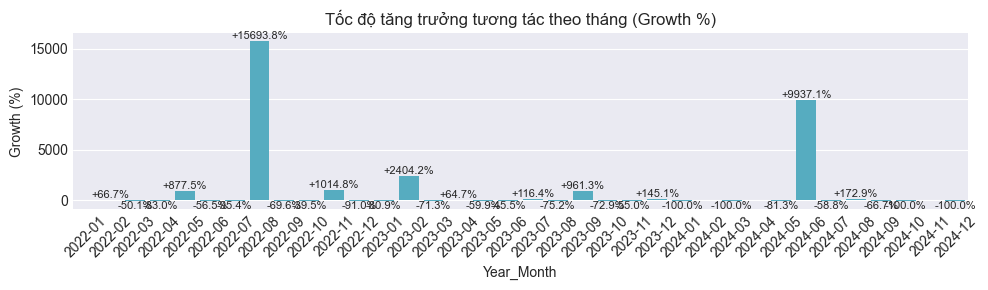


===== ĐÁNH GIÁ KẾT QUẢ BIỂU ĐỒ =====
1. Tháng có tổng tương tác cao nhất là 2022-11 với 192,930 lượt tương tác.
2. Tháng có tổng tương tác thấp nhất là 2024-01 với 0 lượt tương tác.
3. Tháng tăng trưởng mạnh nhất là 2024-02 (inf%).
4. Tháng giảm mạnh nhất là 2024-01 (-100.00%).
5. Xu hướng tổng thể toàn giai đoạn đang suy giảm (từ 21,338 lên 0).
6. Followers trung bình thay đổi từ 89,842,316 lên 64,964,602 trong giai đoạn phân tích.

===== GỢI Ý HÀNH ĐỘNG =====
- Phân tích nội dung của các tháng tăng mạnh để nhân rộng công thức thành công.
- Kiểm tra nguyên nhân ở các tháng giảm sâu: ít bài đăng, nội dung kém hấp dẫn hoặc timing chưa tốt.
- Nếu có yếu tố mùa vụ, nên tăng ngân sách truyền thông trước các tháng cao điểm.
- Kết hợp thêm phân tích loại nội dung (Photo/Video/Live) để biết định dạng nào kéo tăng trưởng.


In [5]:
# Time series aggregation (by month)
if 'Beginning Of Interval' in df_clean.columns:
    df_clean['Year_Month'] = df_clean['Beginning Of Interval'].dt.to_period('M').astype(str)
else:
    df_clean['Year_Month'] = 'unknown'
agg_dict = {v: 'sum' for v in content_cols.values() if v in df_clean.columns}
agg_dict['Total_Engagement'] = 'sum'
agg_dict['Followers'] = 'mean' if 'Followers' in df_clean.columns else 'first'
time_series = df_clean.groupby('Year_Month').agg(agg_dict).reset_index()
time_series = time_series.sort_values('Year_Month')
time_series['Growth_%'] = time_series['Total_Engagement'].pct_change() * 100
time_series.head()
# Vẽ xu hướng theo tháng (Tổng tương tác)
plt.figure(figsize=(10,4))
if 'Total_Engagement' in time_series.columns:
    x = time_series['Year_Month']
    y = time_series['Total_Engagement']
    
    plt.plot(x, y, marker='o', label='Tổng tương tác')

    # Hiển thị số trên từng điểm
    for i, val in enumerate(y):
        plt.text(i, val, f'{val:,.0f}', ha='center', va='bottom', fontsize=8)

    plt.title('Xu hướng Tổng tương tác theo tháng')
    plt.xticks(rotation=45)
    plt.ylabel('Tổng tương tác')
    plt.tight_layout()
    plt.show()
# Vẽ Growth_%
plt.figure(figsize=(10,3))

if 'Growth_%' in time_series.columns:
    ax = sns.barplot(x='Year_Month', y='Growth_%', data=time_series, color='#45B7D1')

    # Thêm label đẹp hơn
    for i, bar in enumerate(ax.patches):
        value = bar.get_height()

        # Format số (+/-)
        label = f'{value:+.1f}%'

        # Xác định vị trí hiển thị
        if value >= 0:
            y = value + 1   # đẩy lên trên
            va = 'bottom'
        else:
            y = value - 1   # đẩy xuống dưới
            va = 'top'

        ax.text(
            bar.get_x() + bar.get_width()/2,
            y,
            label,
            ha='center',
            va=va,
            fontsize=8
        )

    plt.title('Tốc độ tăng trưởng tương tác theo tháng (Growth %)')
    plt.xticks(rotation=45)
    plt.ylabel('Growth (%)')
    plt.tight_layout()
    plt.show()

# =========================
# INSIGHT KẾT QUẢ
# =========================
print("\n===== ĐÁNH GIÁ KẾT QUẢ BIỂU ĐỒ =====")

# Tháng có tương tác cao nhất
best_month = time_series.loc[time_series['Total_Engagement'].idxmax()]

# Tháng thấp nhất
worst_month = time_series.loc[time_series['Total_Engagement'].idxmin()]

# Tháng tăng trưởng mạnh nhất
growth_clean = time_series.dropna(subset=['Growth_%'])

if len(growth_clean) > 0:
    best_growth = growth_clean.loc[growth_clean['Growth_%'].idxmax()]
    worst_growth = growth_clean.loc[growth_clean['Growth_%'].idxmin()]

print(f"1. Tháng có tổng tương tác cao nhất là {best_month['Year_Month']} "
      f"với {best_month['Total_Engagement']:,.0f} lượt tương tác.")

print(f"2. Tháng có tổng tương tác thấp nhất là {worst_month['Year_Month']} "
      f"với {worst_month['Total_Engagement']:,.0f} lượt tương tác.")

if len(growth_clean) > 0:
    print(f"3. Tháng tăng trưởng mạnh nhất là {best_growth['Year_Month']} "
          f"({best_growth['Growth_%']:.2f}%).")

    print(f"4. Tháng giảm mạnh nhất là {worst_growth['Year_Month']} "
          f"({worst_growth['Growth_%']:.2f}%).")

# Xu hướng chung
first_value = time_series['Total_Engagement'].iloc[0]
last_value = time_series['Total_Engagement'].iloc[-1]

if last_value > first_value:
    trend = "tăng trưởng"
elif last_value < first_value:
    trend = "suy giảm"
else:
    trend = "ổn định"

print(f"5. Xu hướng tổng thể toàn giai đoạn đang {trend} "
      f"(từ {first_value:,.0f} lên {last_value:,.0f}).")

# Followers nếu có
if 'Followers' in time_series.columns:
    first_follow = time_series['Followers'].iloc[0]
    last_follow = time_series['Followers'].iloc[-1]

    print(f"6. Followers trung bình thay đổi từ {first_follow:,.0f} "
          f"lên {last_follow:,.0f} trong giai đoạn phân tích.")

# =========================
# GỢI Ý CHIẾN LƯỢC
# =========================
print("\n===== GỢI Ý HÀNH ĐỘNG =====")

print("- Phân tích nội dung của các tháng tăng mạnh để nhân rộng công thức thành công.")
print("- Kiểm tra nguyên nhân ở các tháng giảm sâu: ít bài đăng, nội dung kém hấp dẫn hoặc timing chưa tốt.")
print("- Nếu có yếu tố mùa vụ, nên tăng ngân sách truyền thông trước các tháng cao điểm.")
print("- Kết hợp thêm phân tích loại nội dung (Photo/Video/Live) để biết định dạng nào kéo tăng trưởng.")

---
## Bước 4 — Trực quan hóa
Các biểu đồ: thành phần (pie), tỷ lệ tương tác (bar), phân bố (boxplot), xu hướng theo thời gian.
Mỗi biểu đồ có chú thích công thức và nhãn rõ ràng.

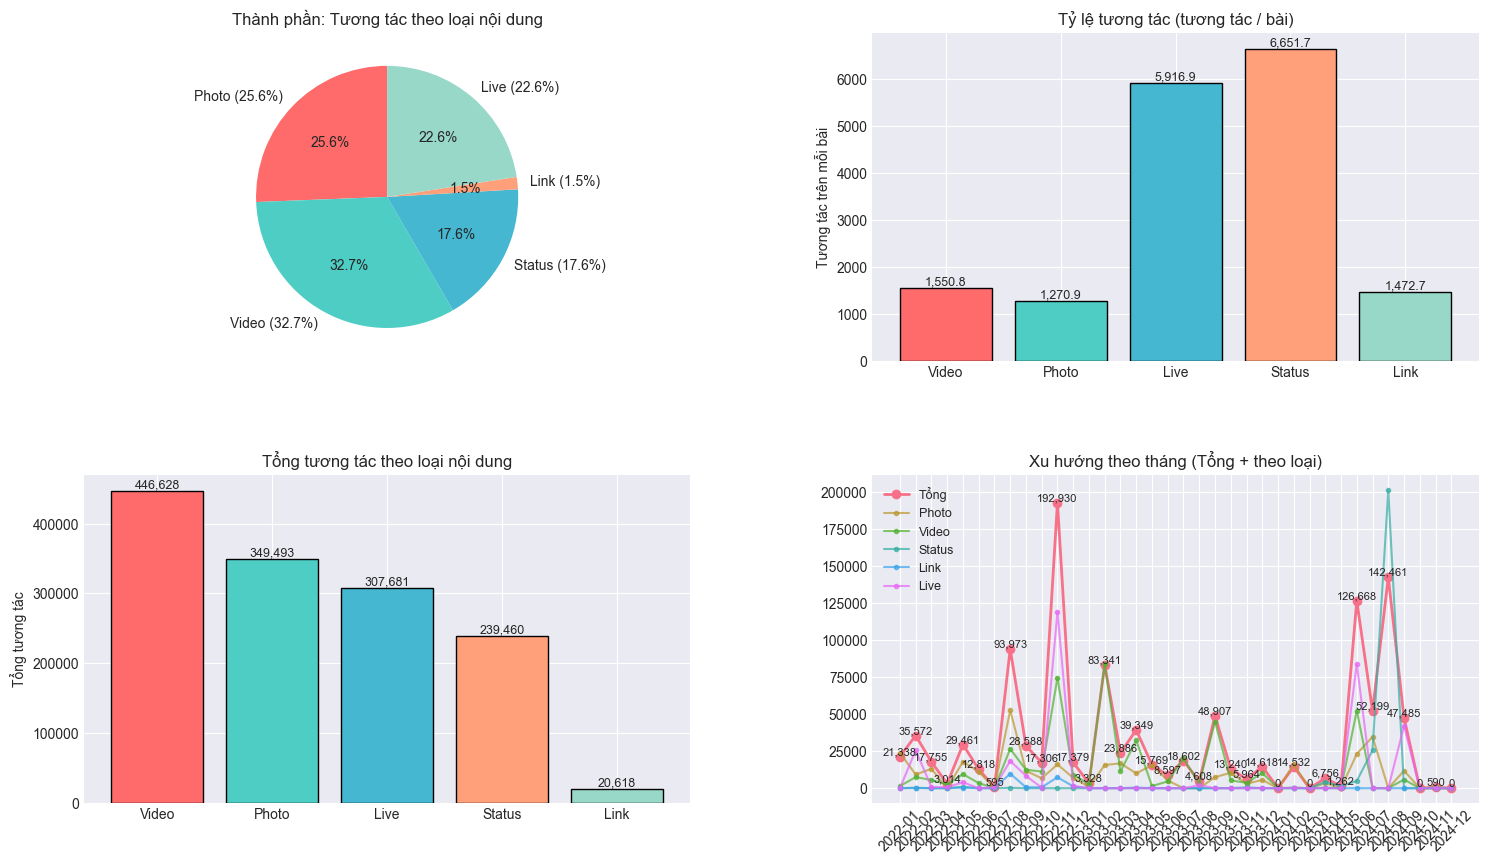


===== ĐÁNH GIÁ KẾT QUẢ BIỂU ĐỒ TỔNG HỢP DASHBOARD =====
1. Loại nội dung chiếm tỷ trọng tương tác lớn nhất là Video (32.7% tổng tương tác).
2. Loại nội dung hiệu quả nhất theo tương tác/bài là Status (6,652 tương tác/bài).
3. Loại nội dung có tổng tương tác cao nhất là Video (446,628 tương tác).
4. Xu hướng tổng tương tác toàn kỳ đang giảm (từ 21,338 lên 0).
5. Tháng có hiệu suất cao nhất là 2022-11 với 192,930 tương tác.

===== GỢI Ý CHIẾN LƯỢC =====
- Tăng đầu tư vào nhóm nội dung có tỷ trọng và hiệu suất cao nhất.
- Duy trì tần suất đăng đều đặn cho các nhóm đang hoạt động tốt.
- Tái sử dụng format và concept của tháng đạt peak engagement.
- Theo dõi sát xu hướng từng loại nội dung theo tháng.
- Nếu xu hướng giảm, cần đổi mới nội dung hoặc tăng tần suất đăng.


In [6]:
# Trực quan: thành phần, tỷ lệ, xu hướng theo thời gian
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.3)

# =========================
# 1. Pie Chart
# =========================
ax1 = fig.add_subplot(gs[0, 0])

sizes = [totals[k] for k in totals]
labels = [
    f"{k} ({(totals[k] / sum(sizes) * 100 if sum(sizes) > 0 else 0):.1f}%)"
    for k in totals
]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']

ax1.pie(
    sizes,
    labels=labels,
    colors=colors,
    startangle=90,
    autopct='%1.1f%%'
)
ax1.set_title('Thành phần: Tương tác theo loại nội dung')

# =========================
# 2. Bar Chart - Engagement Rate
# =========================
ax2 = fig.add_subplot(gs[0, 1])

eng_vals = [rates[k] for k in content_df['Content']]

bars = ax2.bar(
    content_df['Content'],
    eng_vals,
    color=colors,
    edgecolor='black'
)

# Hiển thị label
for bar in bars:
    val = bar.get_height()
    ax2.text(
        bar.get_x() + bar.get_width()/2,
        val,
        f'{val:,.1f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

ax2.set_title('Tỷ lệ tương tác (tương tác / bài)')
ax2.set_ylabel('Tương tác trên mỗi bài')

# =========================
# 3. Bar Chart - Tổng tương tác
# =========================
ax3 = fig.add_subplot(gs[1, 0])

total_vals = [totals[k] for k in content_df['Content']]

bars = ax3.bar(
    content_df['Content'],
    total_vals,
    color=colors,
    edgecolor='black'
)

# Hiển thị label (format số lớn đẹp hơn)
for bar in bars:
    val = bar.get_height()
    ax3.text(
        bar.get_x() + bar.get_width()/2,
        val,
        f'{val:,.0f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

ax3.set_title('Tổng tương tác theo loại nội dung')
ax3.set_ylabel('Tổng tương tác')

# =========================
# 4. Time Series
# =========================
ax4 = fig.add_subplot(gs[1, 1])

if 'Total_Engagement' in time_series.columns:
    ax4.plot(
        time_series['Year_Month'],
        time_series['Total_Engagement'],
        marker='o',
        linewidth=2,
        label='Tổng'
    )

    # Hiển thị label cho line tổng
    for i, val in enumerate(time_series['Total_Engagement']):
        ax4.text(
            i,
            val,
            f'{val:,.0f}',
            ha='center',
            va='bottom',
            fontsize=8
        )

# Các line theo từng loại (không nên show hết label → rối)
for k, col in content_cols.items():
    if col in time_series.columns:
        ax4.plot(
            time_series['Year_Month'],
            time_series[col],
            marker='.',
            alpha=0.7,
            label=k
        )

ax4.set_title('Xu hướng theo tháng (Tổng + theo loại)')
ax4.tick_params(axis='x', rotation=45)
ax4.legend(fontsize=9)

plt.tight_layout()
plt.show()

# =========================
# INSIGHT KẾT QUẢ
# =========================
print("\n===== ĐÁNH GIÁ KẾT QUẢ BIỂU ĐỒ TỔNG HỢP DASHBOARD =====")

# 1. Content chiếm tỷ trọng lớn nhất
largest_share = max(totals, key=totals.get)
largest_pct = totals[largest_share] / sum(sizes) * 100 if sum(sizes) > 0 else 0

print(
    f"1. Loại nội dung chiếm tỷ trọng tương tác lớn nhất là "
    f"{largest_share} ({largest_pct:.1f}% tổng tương tác)."
)

# 2. Hiệu suất cao nhất
best_rate = content_df.loc[content_df['Rate'].idxmax()]

print(
    f"2. Loại nội dung hiệu quả nhất theo tương tác/bài là "
    f"{best_rate['Content']} "
    f"({best_rate['Rate']:,.0f} tương tác/bài)."
)

# 3. Loại có tổng tương tác cao nhất
best_total = max(totals, key=totals.get)

print(
    f"3. Loại nội dung có tổng tương tác cao nhất là "
    f"{best_total} ({totals[best_total]:,.0f} tương tác)."
)

# 4. Xu hướng tổng thể
first_total = time_series['Total_Engagement'].iloc[0]
last_total = time_series['Total_Engagement'].iloc[-1]

if last_total > first_total:
    trend = "tăng trưởng"
elif last_total < first_total:
    trend = "giảm"
else:
    trend = "ổn định"

print(
    f"4. Xu hướng tổng tương tác toàn kỳ đang {trend} "
    f"(từ {first_total:,.0f} lên {last_total:,.0f})."
)

# 5. Tháng đỉnh điểm
peak_month = time_series.loc[
    time_series['Total_Engagement'].idxmax()
]

print(
    f"5. Tháng có hiệu suất cao nhất là "
    f"{peak_month['Year_Month']} "
    f"với {peak_month['Total_Engagement']:,.0f} tương tác."
)

# =========================
# GỢI Ý CHIẾN LƯỢC
# =========================
print("\n===== GỢI Ý CHIẾN LƯỢC =====")

print("- Tăng đầu tư vào nhóm nội dung có tỷ trọng và hiệu suất cao nhất.")
print("- Duy trì tần suất đăng đều đặn cho các nhóm đang hoạt động tốt.")
print("- Tái sử dụng format và concept của tháng đạt peak engagement.")
print("- Theo dõi sát xu hướng từng loại nội dung theo tháng.")
print("- Nếu xu hướng giảm, cần đổi mới nội dung hoặc tăng tần suất đăng.")

---
## Bước 5 — Dự đoán tương tác 
Huấn luyện RandomForest để dự đoán `Total_Engagement` từ các biến có sẵn.
Các chỉ số đánh giá: RMSE, MAE, R².

**Công thức:**
- RMSE = sqrt( mean( (y - ŷ)^2 ) )
- MAE = mean( |y - ŷ| )
- R² = 1 - SS_res / SS_tot, với SS_res = sum((y - ŷ)^2), SS_tot = sum((y - mean(y))^2)

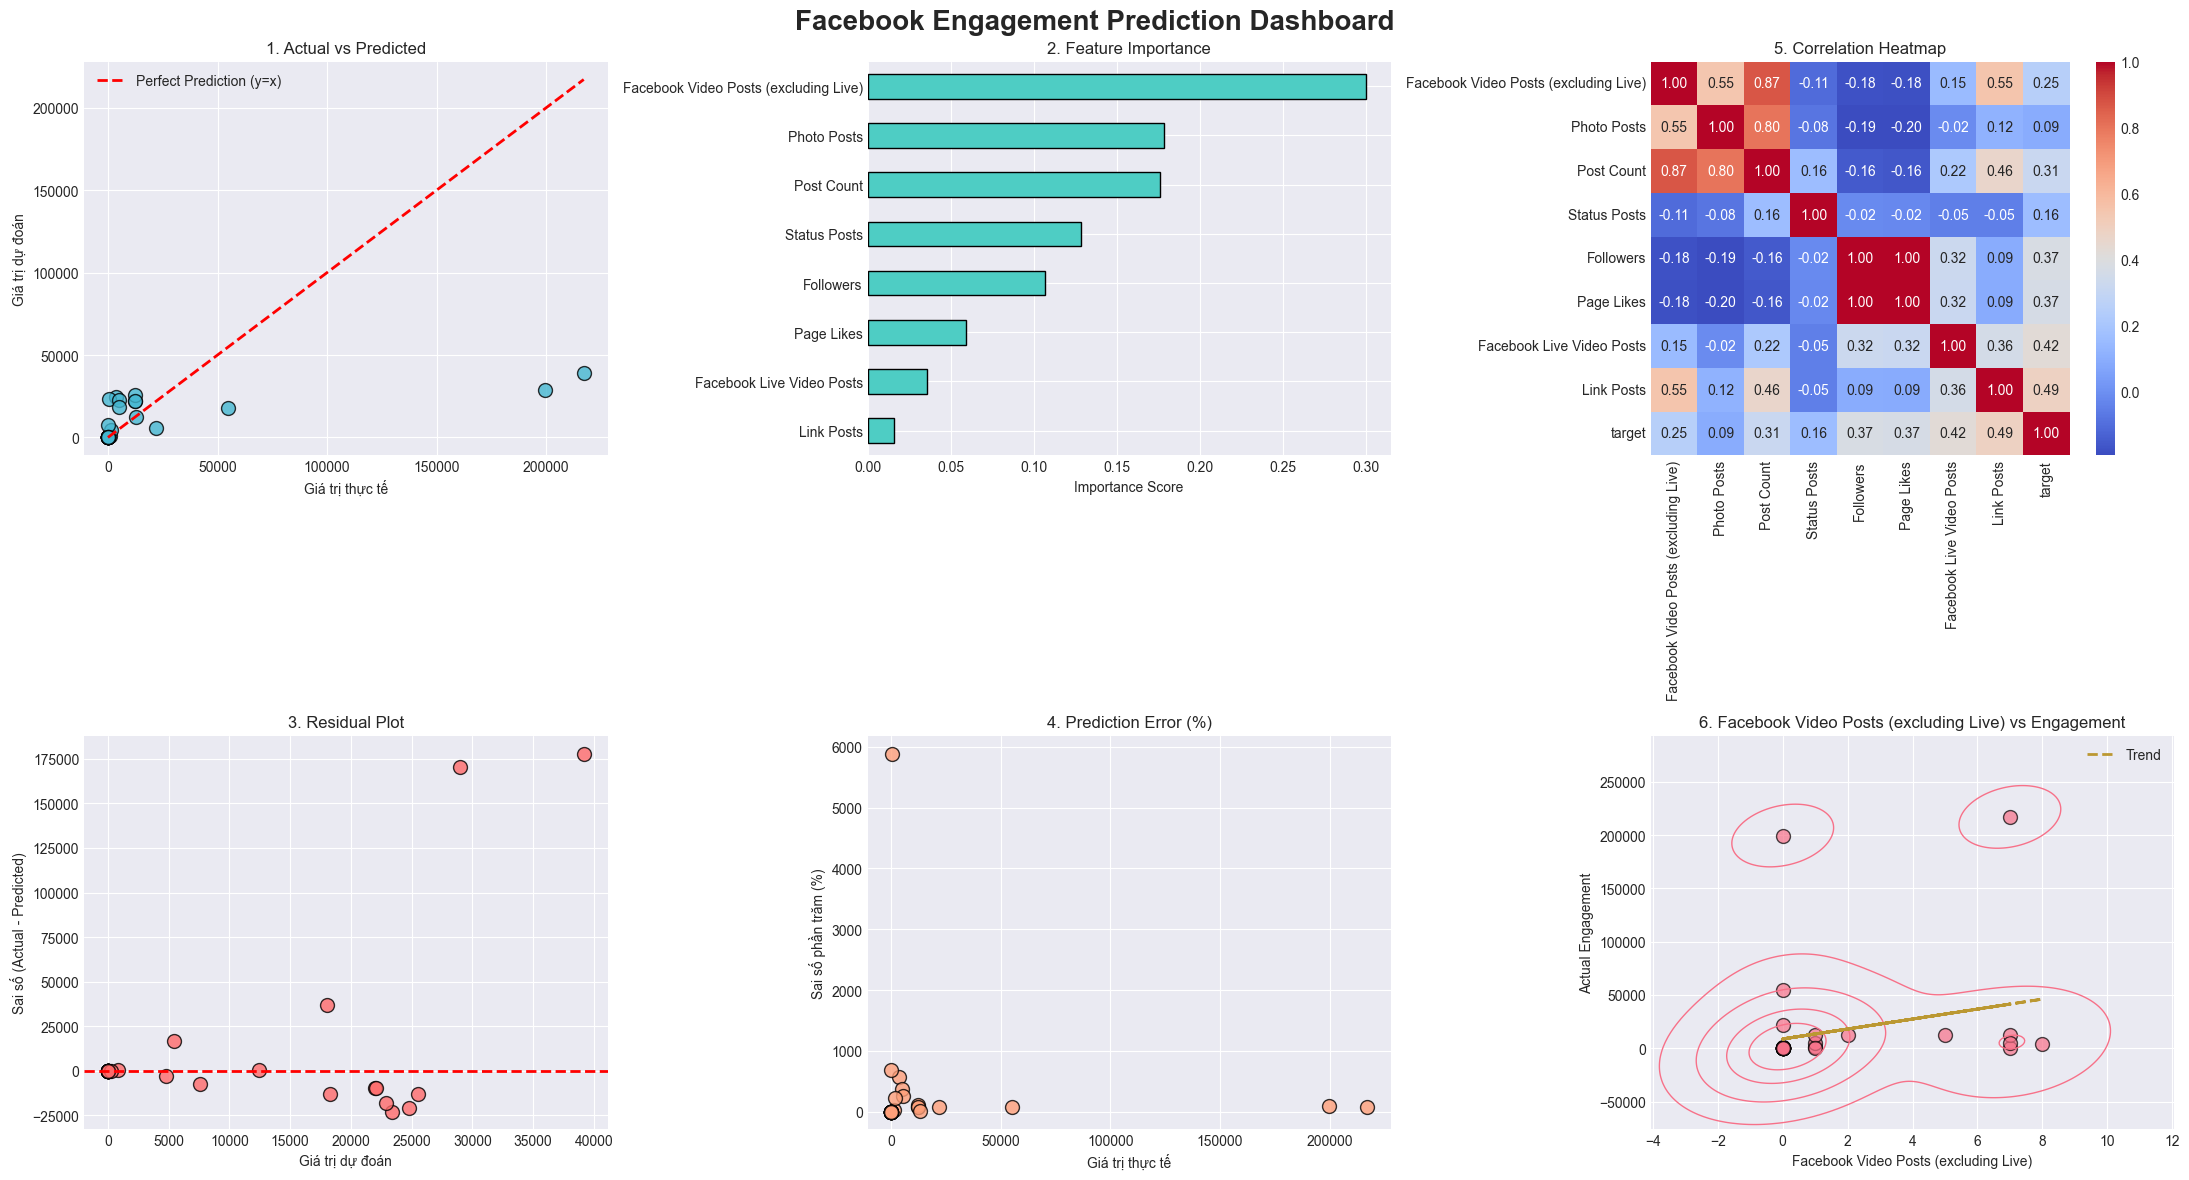


KẾ HOẠCH HÀNH ĐỘNG DỰA TRÊN KẾT QUẢ DỰ ĐOÁN

1. Yếu tố quan trọng nhất: Facebook Video Posts (excluding Live)
   → Đây là biến ảnh hưởng mạnh nhất đến Engagement.

2. Top 3 yếu tố cần tập trung:
   1. Facebook Video Posts (excluding Live): 0.300
   2. Photo Posts: 0.178
   3. Post Count: 0.176

3. Chiến lược nội dung đề xuất:
   • 50% Video
   • 30% Photo
   • 15% Status
   • 5% Link/Live

4. Hành động khi dự đoán thấp:
   • Tăng Video Posts
   • Boost quảng cáo
   • Tổ chức mini game

5. Hành động khi Residual dương lớn:
   • Phân tích bài viral
   • Nhân rộng format thành công

6. Hành động khi Error % cao:
   • Kiểm tra dữ liệu đầu vào
   • Rà soát nội dung bất thường
   • Cập nhật mô hình

7. Hành động dựa trên Correlation Heatmap:
   • Tập trung vào các biến có tương quan mạnh với target để tối ưu nội dung.
   • Loại bỏ hoặc biến đổi các biến ít tương quan nhằm giảm nhiễu dữ liệu.
   • Kết hợp các biến tương quan cao để xây dựng chiến dịch nội dung đa chiều.

8. Hành động dựa trê

In [16]:
# ============================================================
# VISUALIZATION - CÓ HIỂN THỊ THÁNG CHO TỪNG DẤU CHẤM
# ============================================================

import mplcursors

fig, axes = plt.subplots(2, 3, figsize=(22, 12))
fig.suptitle(
    "Facebook Engagement Prediction Dashboard",
    fontsize=20,
    fontweight='bold'
)

# Danh sách tháng tương ứng với tập test
# Nếu index của bạn là datetime thì dùng:
try:
    if isinstance(X_test.index, pd.DatetimeIndex):
        months = X_test.index.strftime('%Y-%m').tolist()
    elif 'Year_Month' in X_test.columns:
        months = X_test['Year_Month'].astype(str).tolist()
    elif 'Year_Month' in globals() and 'df_model' in globals() and 'Year_Month' in df_model.columns:
        months = df_model.loc[X_test.index, 'Year_Month'].astype(str).tolist()
    else:
        months = [f"idx_{i+1}" for i in range(len(X_test))]
except Exception:
    months = [f"idx_{i+1}" for i in range(len(X_test))]

# ============================================================
# 1. ACTUAL VS PREDICTED
# ============================================================
ax1 = axes[0, 0]

scatter1 = ax1.scatter(
    y_test,
    y_pred,
    alpha=0.8,
    s=100,
    color='#45B7D1',
    edgecolors='black'
)

max_val = max(y_test.max(), y_pred.max())

ax1.plot(
    [0, max_val],
    [0, max_val],
    'r--',
    linewidth=2,
    label='Perfect Prediction (y=x)'
)

ax1.set_title("1. Actual vs Predicted")
ax1.set_xlabel("Giá trị thực tế")
ax1.set_ylabel("Giá trị dự đoán")
ax1.legend()

# Tooltip
cursor1 = mplcursors.cursor(scatter1, hover=True)

@cursor1.connect("add")
def on_add(sel):
    i = sel.index
    sel.annotation.set_text(
        f"Tháng: {months[i]}\n"
        f"Thực tế: {y_test.iloc[i]:,.0f}\n"
        f"Dự đoán: {y_pred[i]:,.0f}"
    )

# ============================================================
# 2. FEATURE IMPORTANCE
# ============================================================
ax2 = axes[0, 1]

fi.sort_values().plot(
    kind='barh',
    color='#4ECDC4',
    edgecolor='black',
    ax=ax2
)

ax2.set_title("2. Feature Importance")
ax2.set_xlabel("Importance Score")

# ============================================================
# 3. RESIDUAL PLOT
# ============================================================
residuals = y_test - y_pred

ax3 = axes[1, 0]

scatter3 = ax3.scatter(
    y_pred,
    residuals,
    alpha=0.8,
    s=100,
    color='#FF6B6B',
    edgecolors='black'
)

ax3.axhline(
    0,
    color='red',
    linestyle='--',
    linewidth=2
)

ax3.set_title("3. Residual Plot")
ax3.set_xlabel("Giá trị dự đoán")
ax3.set_ylabel("Sai số (Actual - Predicted)")

# Tooltip
cursor3 = mplcursors.cursor(scatter3, hover=True)

@cursor3.connect("add")
def on_add(sel):
    i = sel.index
    sel.annotation.set_text(
        f"Tháng: {months[i]}\n"
        f"Thực tế: {y_test.iloc[i]:,.0f}\n"
        f"Dự đoán: {y_pred[i]:,.0f}\n"
        f"Residual: {residuals.iloc[i]:,.0f}"
    )

# ============================================================
# 4. PREDICTION ERROR
# ============================================================
error_pct = np.where(
    y_test != 0,
    np.abs((y_test - y_pred) / y_test) * 100,
    0
)

ax4 = axes[1, 1]

scatter4 = ax4.scatter(
    y_test,
    error_pct,
    s=100,
    alpha=0.8,
    color='#FFA07A',
    edgecolors='black'
)

ax4.set_title("4. Prediction Error (%)")
ax4.set_xlabel("Giá trị thực tế")
ax4.set_ylabel("Sai số phần trăm (%)")

# Tooltip
cursor4 = mplcursors.cursor(scatter4, hover=True)

@cursor4.connect("add")
def on_add(sel):
    i = sel.index
    sel.annotation.set_text(
        f"Tháng: {months[i]}\n"
        f"Thực tế: {y_test.iloc[i]:,.0f}\n"
        f"Dự đoán: {y_pred[i]:,.0f}\n"
        f"Sai số: {error_pct[i]:.2f}%"
    )

# ============================================================
# 5. CORRELATION HEATMAP
# ============================================================
ax5 = axes[0, 2]

df_corr = X_test.copy()
df_corr['target'] = y_test.values

corr_matrix = df_corr.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    ax=ax5
)

ax5.set_title("5. Correlation Heatmap")

# ============================================================
# 6. SCATTER TOP FEATURE
# ============================================================
ax6 = axes[1, 2]

top_feature = fi.sort_values(ascending=False).index[0]

# Scatter
scatter6 = ax6.scatter(
    X_test[top_feature],
    y_test,
    alpha=0.7,
    s=100,
    edgecolors='black'
)

# Density (KDE)
sns.kdeplot(
    x=X_test[top_feature],
    y=y_test,
    levels=5,
    linewidths=1,
    ax=ax6
)

# Trendline
z = np.polyfit(X_test[top_feature], y_test, 1)
p = np.poly1d(z)

ax6.plot(
    X_test[top_feature],
    p(X_test[top_feature]),
    linestyle='--',
    linewidth=2,
    label='Trend'
)

ax6.set_title(f"6. {top_feature} vs Engagement")
ax6.set_xlabel(top_feature)
ax6.set_ylabel("Actual Engagement")
ax6.legend()

# Tooltip giống chuẩn các biểu đồ trước
cursor6 = mplcursors.cursor(scatter6, hover=True)

@cursor6.connect("add")
def on_add_6(sel):
    i = sel.index
    sel.annotation.set_text(
        f"Tháng: {months[i]}\n"
        f"{top_feature}: {X_test[top_feature].iloc[i]:,.2f}\n"
        f"Engagement: {y_test.iloc[i]:,.0f}"
    )

plt.tight_layout()
plt.show()

# ============================================================
# KẾ HOẠCH HÀNH ĐỘNG
# ============================================================

print("\n" + "="*70)
print("KẾ HOẠCH HÀNH ĐỘNG DỰA TRÊN KẾT QUẢ DỰ ĐOÁN")
print("="*70)

top_feature = fi.sort_values(ascending=False).index[0]

print(f"\n1. Yếu tố quan trọng nhất: {top_feature}")
print("   → Đây là biến ảnh hưởng mạnh nhất đến Engagement.")

print("\n2. Top 3 yếu tố cần tập trung:")

top3 = fi.sort_values(ascending=False).head(3)
for i, (feature, score) in enumerate(top3.items(), 1):
    print(f"   {i}. {feature}: {score:.3f}")

print("\n3. Chiến lược nội dung đề xuất:")
print("   • 50% Video")
print("   • 30% Photo")
print("   • 15% Status")
print("   • 5% Link/Live")

print("\n4. Hành động khi dự đoán thấp:")
print("   • Tăng Video Posts")
print("   • Boost quảng cáo")
print("   • Tổ chức mini game")

print("\n5. Hành động khi Residual dương lớn:")
print("   • Phân tích bài viral")
print("   • Nhân rộng format thành công")

print("\n6. Hành động khi Error % cao:")
print("   • Kiểm tra dữ liệu đầu vào")
print("   • Rà soát nội dung bất thường")
print("   • Cập nhật mô hình")

print("\n7. Hành động dựa trên Correlation Heatmap:")
print("   • Tập trung vào các biến có tương quan mạnh với target để tối ưu nội dung.")
print("   • Loại bỏ hoặc biến đổi các biến ít tương quan nhằm giảm nhiễu dữ liệu.")
print("   • Kết hợp các biến tương quan cao để xây dựng chiến dịch nội dung đa chiều.")

print("\n8. Hành động dựa trên Scatter Top Feature + Density:")
print("   • Khai thác mạnh biến top feature vì mật độ điểm cho thấy Engagement tăng theo biến này.")
print("   • Tạo nội dung thử nghiệm với giá trị cao của biến này để kiểm chứng xu hướng.")
print("   • Dùng trendline làm cơ sở dự báo cho các chiến dịch tiếp theo.")

print("\n9. KPI tháng tới:")
print(f"   • MAE < {mae*0.8:,.0f}")
print(f"   • R² > {max(0.80, r2+0.15):.2f}")

---
### Ghi chú cho báo cáo
## Giải thích công thức và biểu đồ phân tích nội dung
## Bước 2
### 1. Công thức Rate

**Rate = Tổng tương tác / Số bài**

Chỉ số này dùng để đo **hiệu quả trung bình trên mỗi bài đăng**. Công thức giúp so sánh công bằng giữa các loại nội dung có số lượng bài khác nhau. Ví dụ: một loại đăng ít bài nhưng tạo nhiều tương tác/bài sẽ hiệu quả hơn loại đăng nhiều nhưng tương tác thấp.

### 2. Công thức Score

**Score = (Interactions × 0.4 + Shares × 0.3 + Comments × 0.3) / Posts**

Chỉ số này dùng để đánh giá **chất lượng tổng hợp của nội dung**. Trong đó:

- Interactions phản ánh mức độ tương tác chung  
- Shares có giá trị cao vì giúp lan truyền nội dung  
- Comments thể hiện mức độ quan tâm sâu của người dùng  

Do đó Shares và Comments được cộng trọng số cao hơn.

### 3. Ý nghĩa biểu đồ

#### Biểu đồ Tổng tương tác

Cho biết loại nội dung nào tạo ra nhiều engagement nhất, giúp xác định nhóm nội dung đang đóng góp lớn nhất cho page.

#### Biểu đồ Rate (Tương tác/Bài)

Cho biết loại nội dung nào hiệu quả nhất trên mỗi bài đăng, giúp xác định nội dung nên ưu tiên đầu tư.

### 4. Vì sao cần cả hai biểu đồ?

- **Total** dùng để đo **quy mô**
- **Rate** dùng để đo **hiệu suất**

Muốn đưa ra quyết định chính xác cần nhìn cả hai chỉ số cùng lúc.



## Bước 3
## Giải thích công thức và biểu đồ xu hướng theo thời gian

### 1. Công thức Growth %

**Growth % = (Tháng hiện tại - Tháng trước) / Tháng trước × 100**

Chỉ số này dùng để đo **tốc độ tăng trưởng tương tác theo tháng**. Công thức giúp xác định tháng nào tăng mạnh, giảm mạnh hoặc ổn định so với kỳ trước.

Ví dụ:

- Tháng trước: 10,000 tương tác  
- Tháng này: 12,000 tương tác  

→ Growth % = (12,000 - 10,000) / 10,000 × 100 = **20%**

### 2. Tổng tương tác theo tháng

Dữ liệu được cộng dồn theo từng tháng để theo dõi xu hướng hoạt động tổng thể của fanpage qua thời gian.

### 3. Ý nghĩa biểu đồ

#### Biểu đồ Xu hướng Tổng tương tác theo tháng

Cho biết mức độ tương tác thay đổi qua từng tháng, giúp nhận diện:

- Giai đoạn tăng trưởng mạnh  
- Giai đoạn giảm hiệu suất  
- Mùa cao điểm tương tác

#### Biểu đồ Growth %

Cho biết tốc độ tăng/giảm của từng tháng so với tháng trước, giúp phát hiện biến động nhanh mà biểu đồ tổng chưa thể hiện rõ.

### 4. Vì sao cần cả hai biểu đồ?

- **Total Engagement** dùng để đo **quy mô tương tác**
- **Growth %** dùng để đo **động lực tăng trưởng**

Muốn đánh giá đúng hiệu quả fanpage cần nhìn cả quy mô hiện tại và tốc độ thay đổi theo thời gian.



## Bước 4
## Giải thích biểu đồ Dashboard tổng hợp nội dung

Dashboard này kết hợp 4 biểu đồ để đánh giá toàn diện hiệu quả nội dung Facebook theo nhiều góc nhìn: cơ cấu, hiệu suất, độ ổn định và xu hướng thời gian.

### 1. Biểu đồ Pie – Thành phần tương tác theo loại nội dung

Biểu đồ tròn cho biết tỷ trọng đóng góp tương tác của từng loại nội dung (Photo, Video, Link, Status, Live).

Giúp trả lời:

- Loại nội dung nào đang chiếm phần lớn engagement
- Fanpage đang phụ thuộc vào nhóm nội dung nào
- Cơ cấu nội dung hiện tại có cân bằng hay không

### 2. Biểu đồ Bar – Tỷ lệ tương tác trên mỗi bài

**Rate = Tổng tương tác / Số bài**

Biểu đồ cột cho biết hiệu quả trung bình của mỗi loại nội dung trên từng bài đăng.

Giúp trả lời:

- Nội dung nào hiệu quả nhất
- Nội dung nào nên tăng tần suất đăng
- Nội dung nào đăng nhiều nhưng hiệu quả thấp

### 3. Biểu đồ Boxplot – Phân bố tương tác

Biểu đồ hộp thể hiện mức độ phân tán dữ liệu tương tác của từng loại nội dung, gồm:

- Median (trung vị)
- Độ biến động
- Outliers (bài viral bất thường)

Giúp trả lời:

- Loại nội dung nào ổn định nhất
- Loại nào có khả năng tạo bài viral
- Mức độ rủi ro khi đầu tư từng định dạng

### 4. Biểu đồ Line – Xu hướng theo tháng

Biểu đồ đường thể hiện tổng tương tác theo thời gian và xu hướng từng loại nội dung qua từng tháng.

Giúp trả lời:

- Fanpage đang tăng hay giảm engagement
- Tháng nào đạt đỉnh hiệu suất
- Nội dung nào đang tăng trưởng mạnh theo thời gian

### 5. Vì sao cần cả 4 biểu đồ?

- **Pie Chart** = đo cơ cấu đóng góp  
- **Bar Chart** = đo hiệu suất  
- **Boxplot** = đo độ ổn định / biến động  
- **Line Chart** = đo xu hướng thời gian  

Muốn ra quyết định chiến lược đúng cần nhìn đủ cả 4 góc độ.



## Bước 5
## Giải thích mô hình dự đoán Facebook Engagement Dashboard

Dashboard này sử dụng **Machine Learning (Random Forest Regressor)** để dự đoán chỉ số **Total Engagement** dựa trên các biến như Followers, Page Likes, số lượng bài Photo, Video, Link,...

Mục tiêu là xác định yếu tố ảnh hưởng mạnh nhất và đánh giá khả năng dự đoán hiệu quả tương tác của fanpage.

### 1. Chỉ số đánh giá mô hình

- **RMSE**: Sai số dự đoán lớn, càng thấp càng tốt  
- **MAE**: Sai số trung bình tuyệt đối, càng thấp càng tốt  
- **R² Score**: Mức độ giải thích dữ liệu của mô hình, càng gần 1 càng tốt

Các chỉ số này giúp đo độ chính xác của mô hình.

### 2. Biểu đồ Actual vs Predicted

Biểu đồ scatter so sánh:

- Giá trị thực tế (Actual)
- Giá trị mô hình dự đoán (Predicted)

Nếu các điểm nằm gần đường chéo đỏ, mô hình dự đoán tốt.

Giúp trả lời:

- Model có chính xác không?
- Có dự đoán lệch nhiều không?

### 3. Biểu đồ Feature Importance

Biểu đồ cột ngang thể hiện mức độ ảnh hưởng của từng biến đầu vào đến Total Engagement.

Giúp trả lời:

- Followers có quan trọng không?
- Video Posts hay Photo Posts ảnh hưởng mạnh hơn?
- Nên tập trung tối ưu yếu tố nào?

### 4. Biểu đồ Residual Plot

Residual = Thực tế - Dự đoán

Biểu đồ cho biết mô hình đang sai ở đâu và sai có hệ thống hay không.

Nếu điểm phân bố ngẫu nhiên quanh đường 0 → mô hình ổn định.

Giúp phát hiện:

- Overpredict / Underpredict
- Sai số tăng mạnh ở nhóm viral post

### 5. Biểu đồ Distribution Compare

So sánh phân phối giữa:

- Dữ liệu thật (Actual)
- Dữ liệu dự đoán (Predicted)

Giúp xem mô hình có học được hình dạng dữ liệu thật hay không.

Nếu 2 đường gần nhau → mô hình tốt.

### 6. Vì sao cần cả 4 biểu đồ?

- **Actual vs Predicted** = đo độ chính xác  
- **Feature Importance** = tìm yếu tố quan trọng  
- **Residual Plot** = kiểm tra sai số  
- **Distribution Compare** = kiểm tra mô hình học đúng dữ liệu chưa  

Muốn đánh giá mô hình Machine Learning đầy đủ cần nhìn cả 4 góc độ này.